# PREVISAO DE RISCO DE CREDITO COM MACHINE LEARNING 

##### Este projeto tem como objetivo resolver um problema real enfrentado por um banco alemão: clientes que recebem empréstimos, mas nem todos conseguem devolver o valor emprestado, gerando risco de inadimplência para a instituição.

##### Utilizando uma base histórica de clientes classificados como bons ou maus pagadores, o projeto busca construir modelos de Machine Learning Supervisionado capazes de prever se um novo cliente será apto a receber crédito, ajudando o banco a tomar decisões mais embasadas e reduzir perdas financeiras.

irei seguir a seguinte pipiline 
1. definir o problema da empresa
2. coletar a base de dados e ter uma visao geral
3. separar em duas base - (treino/teste)
4. EDA
5. tratamento de dados
6. treinamento dos modelos, e comparação e tuning
7. produto final e priorização
8. conclusões

Nesse notebook irei fazer as etapas de 1-4, com o objtivo de entender o problema e quais são os principais insights valiosas para o problema de risco de crédito, e com base nisso criar um modelo para prever possiveis casos de calote

## 1. Problema a ser resolvido



Risco de crédito é a possibilidade de um cliente não conseguir honrar um compromisso financeiro assumido — ou seja, não pagar total ou parcialmente um empréstimo, financiamento ou dívida contraída junto a uma instituição financeira.

##### Por que os bancos se importam tanto com isso

É o principal risco que uma instituição financeira enfrenta na sua atividade central (emprestar dinheiro). Quando um cliente não paga, o banco perde não só o valor emprestado, mas também os juros que esperava receber — e ainda tem custos de cobrança/recuperação. Multiplicado por milhares de clientes, isso pode comprometer seriamente a saúde financeira da instituição.

Historicamente, essa avaliação era feita manualmente por analistas. Hoje, a maioria dos bancos usa modelos de credit scoring — sistemas de Machine Learning que calculam a probabilidade de inadimplência com base no histórico de clientes anteriores. É esse tipo de modelo que estamos construindo.

In [2]:
#importando as bibliotecas necessarias
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

from EDA_utils import sns_plots, contar_outliers, plot_categoricas_bivariada


## 2. Coletar a base de dados e visao geral

A base de dados foi pego desse url : https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data

In [3]:
# carregar base de dados e renomear as colunas com base na descriçao da base
df = pd.read_csv('german.data', sep=' ', header=None)
nomes_colunas = [
    'checking_account',
    'duration_months',
    'credit_history',
    'purpose',
    'credit_amount',
    'savings_account',
    'employment_since',
    'installment_rate',
    'personal_status_sex',
    'other_debtors',
    'residence_since',
    'property',
    'age',
    'other_installment_plans',
    'housing',
    'existing_credits',
    'job',
    'dependents',
    'telephone',
    'foreign_worker',
    'credit_risk'
]
df.columns = nomes_colunas
# Mapeamento explícito: 1 (Bom Pagador) -> 0 | 2 (Mau Pagador) -> 1
df['credit_risk'] = df['credit_risk'].map({1: 0, 2: 1})

# Converte para inteiro (garante o tipo de dado correto)
df['credit_risk'] = df['credit_risk'].astype(int)

df.head()

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


### Dicionario dos dados

1. checking_account (categórica: A11 - saldo < 0 DM, A12 - 0 a 200 DM, A13 - ≥ 200 DM, A14 - sem conta corrente)
2. duration_months (numérica, em meses)
3. credit_history (categórica: sem crédito/tudo pago, tudo pago neste banco, crédito em dia, atraso no passado, conta crítica)
4. purpose (categórica: carro novo, carro usado, móveis, rádio/TV, eletrodomésticos, reparos, educação, requalificação, negócio, outros)
5. credit_amount (numérica, em DM)
6. savings_account (categórica: < 100 DM, 100-500 DM, 500-1000 DM, ≥ 1000 DM, desconhecido/sem poupança)
7. employment_since (categórica: desempregado, < 1 ano, 1-4 anos, 4-7 anos, ≥ 7 anos)
8. installment_rate (numérica: taxa de prestação em % da renda disponível)
9. personal_status_sex (categórica: sexo + estado civil)
10. other_debtors (categórica: nenhum, co-solicitante, fiador)
11. residence_since (numérica, em anos)
12. property (categórica: imóvel, poupança/seguro de vida, carro ou outro, desconhecido/sem propriedade)
13. age (numérica, em anos)
14. other_installment_plans (categórica: banco, lojas, nenhum)
15. housing (categórica: aluguel, própria, cedida)
16. existing_credits (numérica: número de créditos existentes no banco)
17. job (categórica: não qualificado/não residente, não qualificado/residente, empregado qualificado, gestão/altamente qualificado)
18. dependents (numérica: número de dependentes)
19. telephone (categórica: não tem, tem registrado)
20. foreign_worker (categórica: sim, não)
##### 21. credit_risk (target: bom pagador(0), mau pagador(1))

In [4]:
#informaçoes gerais sobre o df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration_months          1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_since         1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

## 3. Separar a base em dias partes, teste e treino

In [5]:
#separar base de treino e de teste mantendo a proporcao da variavel target
X = df.drop(columns='credit_risk')  
y = df['credit_risk']               

# Fazer o split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    stratify=y,        # qual variável manter a proporção? (dica: a mesma do desbalanceamento)
    random_state=42
)

In [6]:
print(f'base de features treino tem a forma: {X_train.shape}.')
print(f'base de objetivo treino tem a forma: {y_train.shape}.')
print(f'base de features teste tem a forma: {X_test.shape}.')
print(f'base de objetivo teste tem a forma: {y_test.shape}.')

base de features treino tem a forma: (800, 20).
base de objetivo treino tem a forma: (800,).
base de features teste tem a forma: (200, 20).
base de objetivo teste tem a forma: (200,).


In [7]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64
credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64


podemos notar que a proporcao nas duas bases teste e treino estao iguais

## 4. EDA

In [8]:
treino = pd.concat([X_train , y_train],axis = 1)

In [9]:
features_numericas = X_train.select_dtypes('number').columns.tolist()
features_categoricas = X_train.select_dtypes('object').columns.tolist()
print(f'há {len(features_numericas)} features numericas')
print(features_numericas)
print(f'há {len(features_categoricas)} features categoricas')
print(features_categoricas)



há 7 features numericas
['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'dependents']
há 13 features categoricas
['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


Vou analisar os valores únicos das variáveis categóricas. A cardinalidade é um fator importante na escolha de uma técnica de codificação (encoding) para essas variáveis.


In [10]:
for i in features_categoricas:

    print(i)
    print('~'*40)
    print(f'ha {treino[i].nunique()} valores na coluna {i}')
    print(treino[i].value_counts(normalize = True))
    print()
    print()

checking_account
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ha 4 valores na coluna checking_account
checking_account
A14    0.39500
A11    0.27375
A12    0.26750
A13    0.06375
Name: proportion, dtype: float64


credit_history
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ha 5 valores na coluna credit_history
credit_history
A32    0.52000
A34    0.30000
A33    0.09000
A31    0.05125
A30    0.03875
Name: proportion, dtype: float64


purpose
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ha 10 valores na coluna purpose
purpose
A43     0.26875
A40     0.24250
A42     0.18625
A41     0.10500
A49     0.09875
A46     0.05000
A45     0.02250
A44     0.01250
A410    0.00750
A48     0.00625
Name: proportion, dtype: float64


savings_account
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ha 5 valores na coluna savings_account
savings_account
A61    0.59375
A65    0.18000
A62    0.11250
A63    0.06250
A64    0.05125
Name: proportion, dtype: float64


employment_since
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ha 5 va

INSIGHTS

    - Algumas colunas categóricas têm uma ordem natural, como employment_since e job, e podem ser transformadas em variáveis ordinais no pré-processamento. Já checking_account e savings_account também têm ordem, mas exigem atenção por conterem uma categoria de "sem conta/desconhecido".
    
    - Para as colunas sem ordem natural, pode ser interessante separar em duas abordagens: colunas com poucas categorias, como personal_status_sex, other_debtors e housing, podem usar one-hot encoding sem gerar muitas colunas novas.

    - Colunas com mais categorias, como purpose e credit_history, podem ser tratadas com target encoding, evitando criar um número muito grande de colunas novas no dataset.

## analise unvariada

distribuicao do obtivo('credit_risk')

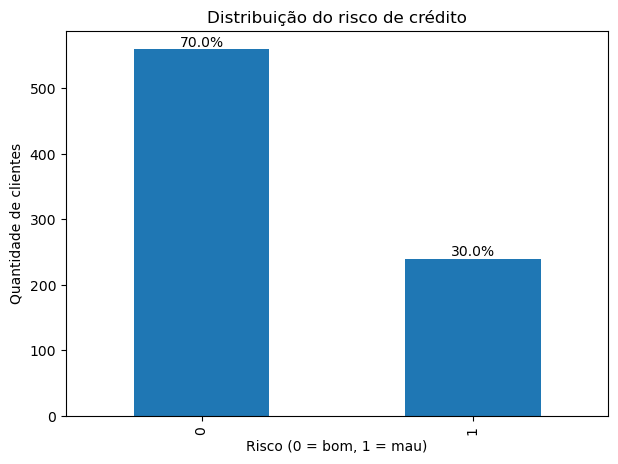

In [11]:

# Gráfico de barras normal
ax = treino['credit_risk'].value_counts().plot(kind='bar', figsize=(7, 5))

# Calcula o total e as porcentagens
total = len(treino)
for barra in ax.patches:
    altura = barra.get_height()
    percentual = (altura / total) * 100
    ax.annotate(f'{percentual:.1f}%', 
                (barra.get_x() + barra.get_width() / 2, altura), 
                ha='center', va='bottom')

plt.title("Distribuição do risco de crédito")
plt.xlabel("Risco (0 = bom, 1 = mau)")
plt.ylabel("Quantidade de clientes")
plt.show()

O alvo (credit_risk) está levemente desbalanceado: 30% dos clientes são de risco ruim (maus pagadores). Como o dataset tem apenas 1000 linhas, algumas estratégias serão adotadas para lidar com isso na etapa de modelagem:

Divisão estratificada e validação cruzada k-fold, para manter a proporção do target nos conjuntos de teste e validação, inclusive durante o ajuste de hiperparâmetros.

Class weights diferenciados para as classes majoritária e minoritária, penalizando mais o modelo quando ele classificar erroneamente um cliente de risco ruim.

Análise do trade-off entre precisão e recall, priorizando um recall alto — já que o objetivo é identificar o máximo possível de clientes de risco ruim, mesmo que isso custe um pouco de precisão.

## Features numericas 

In [12]:
treino[features_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
duration_months,800.0,20.77000,11.817325,4.0,12.0,18.0,24.0,60.0
credit_amount,800.0,3189.59125,2673.547370,276.0,1353.0,2317.0,3933.0,15945.0
installment_rate,800.0,2.94125,1.124446,1.0,2.0,3.0,4.0,4.0
residence_since,800.0,2.83000,1.111370,1.0,2.0,3.0,4.0,4.0
age,800.0,35.32375,11.045313,19.0,27.0,33.0,41.0,75.0
existing_credits,800.0,1.40750,0.567315,1.0,1.0,1.0,2.0,4.0
dependents,800.0,1.16000,0.366835,1.0,1.0,1.0,1.0,2.0


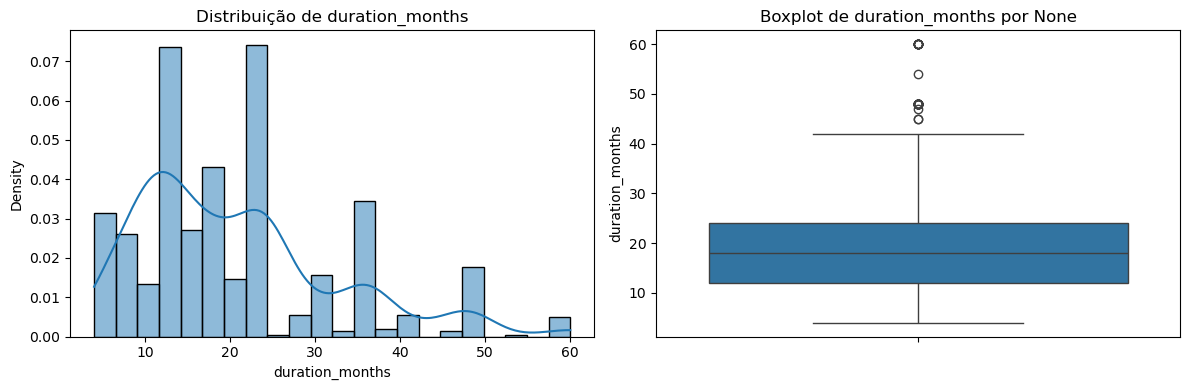

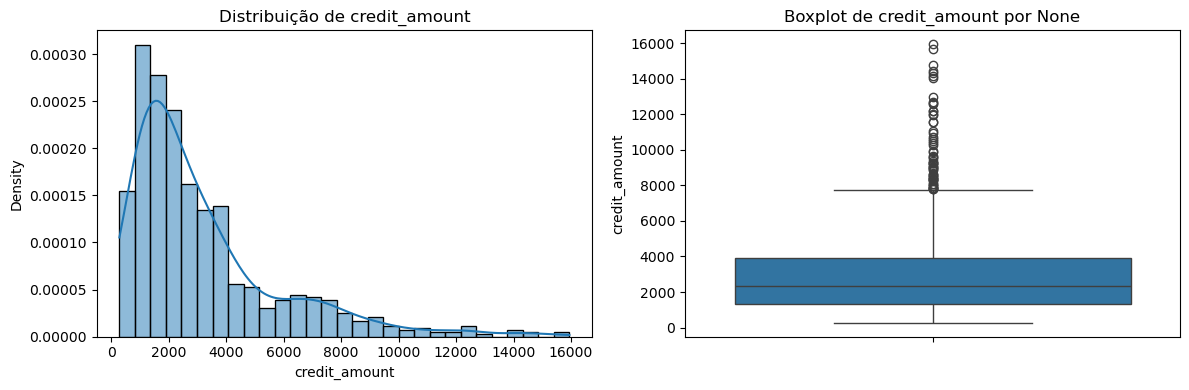

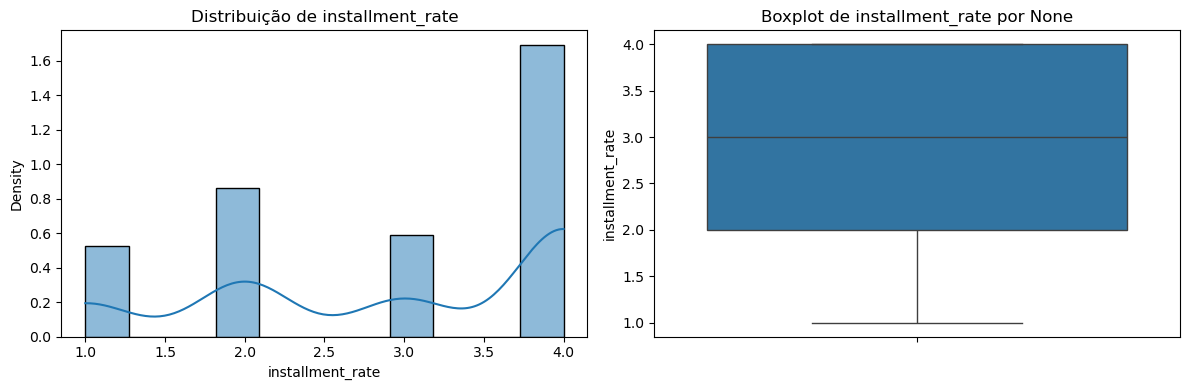

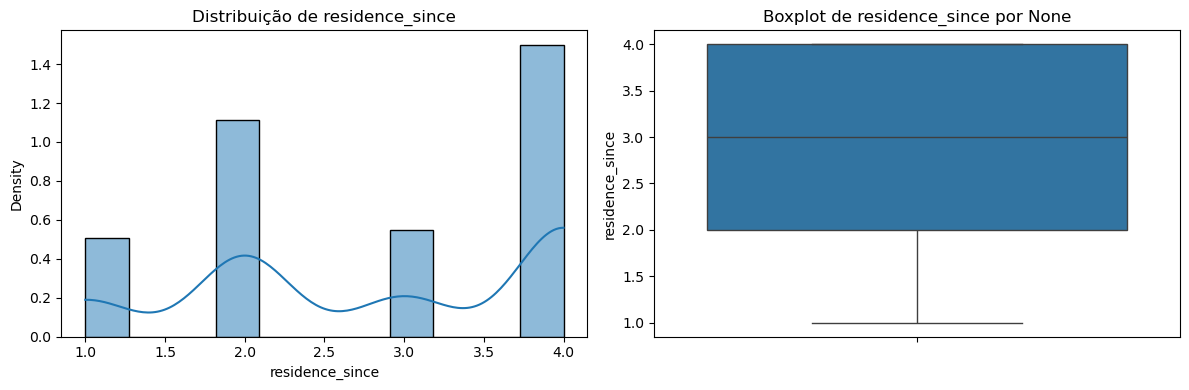

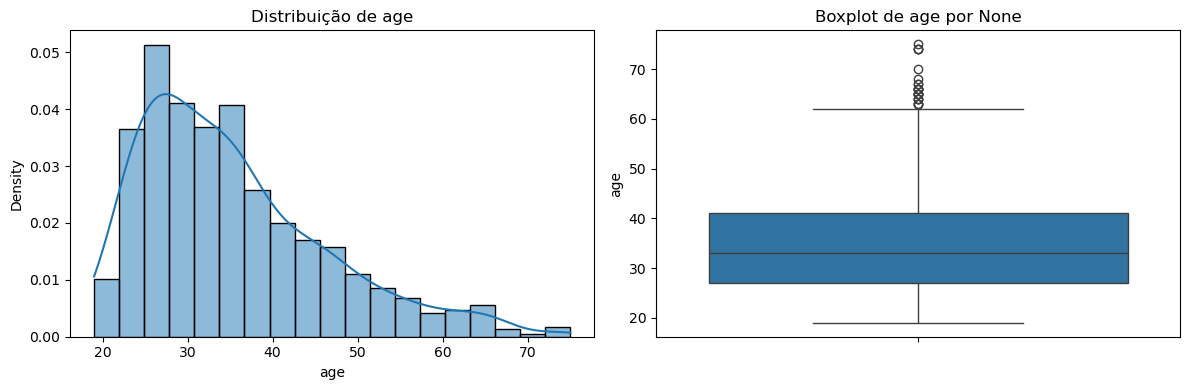

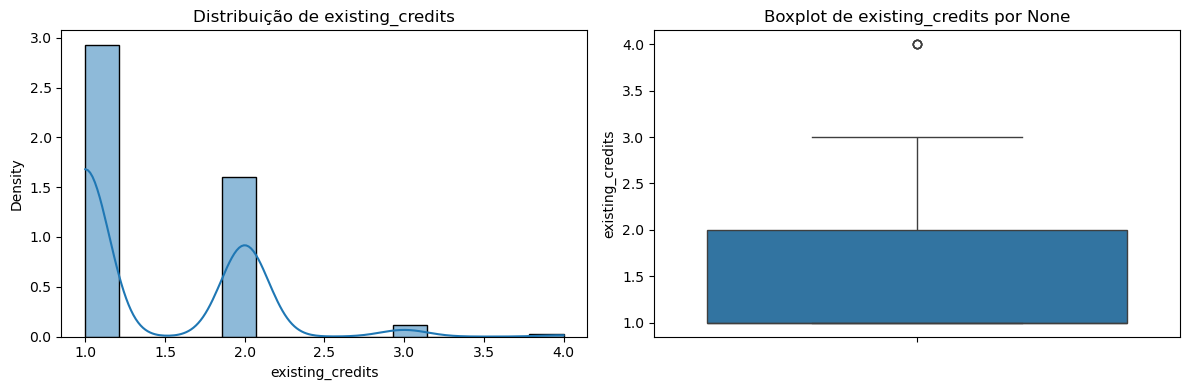

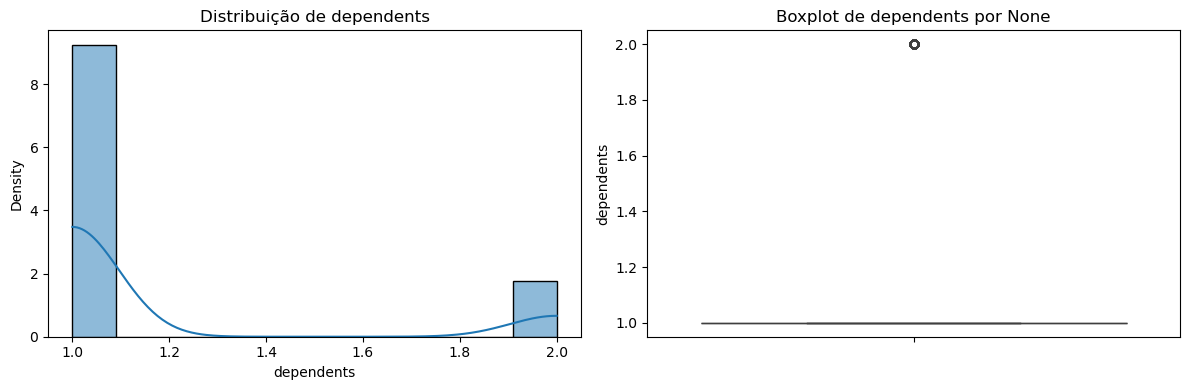

In [13]:
sns_plots(data = treino, features = features_numericas)

In [14]:
tabela_outliers = contar_outliers(treino, features_numericas)
print(tabela_outliers)

             coluna  qtd_outliers  percentual
0   duration_months            50        6.25
1     credit_amount            58        7.25
2  installment_rate             0        0.00
3   residence_since             0        0.00
4               age            25        3.12
5  existing_credits             4        0.50
6        dependents           128       16.00


INSIGHTS

    - Maioria dos emprestimos tem a duração ou de 1 ou 2 anos (12 e 24 meses)
    - Valores de emprestimos menores sao muito comuns, quando maior o valor emprestado, mais esse valor se torna incomum (calda a direta), formando alguns outliers
    - Idade com mais frequencia de emprestimos esta entre 20 a 40 anos
    - há alguns outliers como podemos ver a cima, poré, não e muito interresante tirá-los pois temos apenas 1000 linhas, de qualquer forma esses outliers nao pode ser visto como incosistencia pois sempre existira por exemplo um emprestimo de uma valor extremamente alto 

In [15]:
mapa_categorias = {
    'checking_account': {
        'A11': '< 0 DM',
        'A12': '0 <= ... < 200 DM',
        'A13': '>= 200 DM',
        'A14': 'sem conta corrente'
    },
    'credit_history': {
        'A30': 'sem créditos ou todos pagos',
        'A31': 'créditos deste banco pagos em dia',
        'A32': 'créditos existentes pagos em dia até agora',
        'A33': 'atraso no pagamento no passado',
        'A34': 'conta crítica/outros créditos existentes'
    },
    'purpose': {
        'A40': 'carro novo',
        'A41': 'carro usado',
        'A42': 'móveis/equipamento',
        'A43': 'rádio/televisão',
        'A44': 'eletrodomésticos',
        'A45': 'reparos',
        'A46': 'educação',
        'A47': 'férias',
        'A48': 'requalificação',
        'A49': 'negócio',
        'A410': 'outros'
    },
    'savings_account': {
        'A61': '< 100 DM',
        'A62': '100 <= ... < 500 DM',
        'A63': '500 <= ... < 1000 DM',
        'A64': '>= 1000 DM',
        'A65': 'desconhecido/sem poupança'
    },
    'employment_since': {
        'A71': 'desempregado',
        'A72': '< 1 ano',
        'A73': '1 <= ... < 4 anos',
        'A74': '4 <= ... < 7 anos',
        'A75': '>= 7 anos'
    },
    'personal_status_sex': {
        'A91': 'homem: divorciado/separado',
        'A92': 'mulher: divorciada/separada/casada',
        'A93': 'homem: solteiro',
        'A94': 'homem: casado/viúvo',
        'A95': 'mulher: solteira'
    },
    'other_debtors': {
        'A101': 'nenhum',
        'A102': 'co-solicitante',
        'A103': 'fiador'
    },
    'property': {
        'A121': 'imóvel',
        'A122': 'poupança/seguro de vida',
        'A123': 'carro ou outro',
        'A124': 'desconhecido/sem propriedade'
    },
    'other_installment_plans': {
        'A141': 'banco',
        'A142': 'lojas',
        'A143': 'nenhum'
    },
    'housing': {
        'A151': 'aluguel',
        'A152': 'própria',
        'A153': 'cedida'
    },
    'job': {
        'A171': 'desempregado/não qualificado, não residente',
        'A172': 'não qualificado, residente',
        'A173': 'empregado qualificado',
        'A174': 'gestão/autônomo/altamente qualificado'
    },
    'telephone': {
        'A191': 'não tem',
        'A192': 'tem, registrado no nome do cliente'
    },
    'foreign_worker': {
        'A201': 'sim',
        'A202': 'não'
    }
}

# Aplica o mapeamento em todas as colunas categóricas de uma vez
treino_decodificado = treino.copy()

for coluna, mapa in mapa_categorias.items():
    treino_decodificado[coluna] = treino_decodificado[coluna].map(mapa)

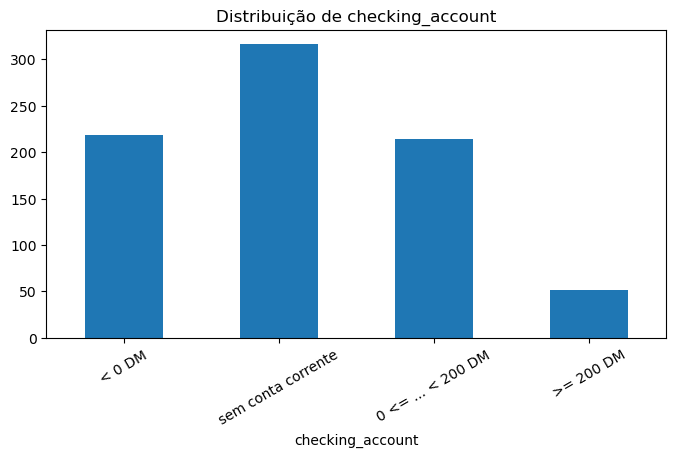

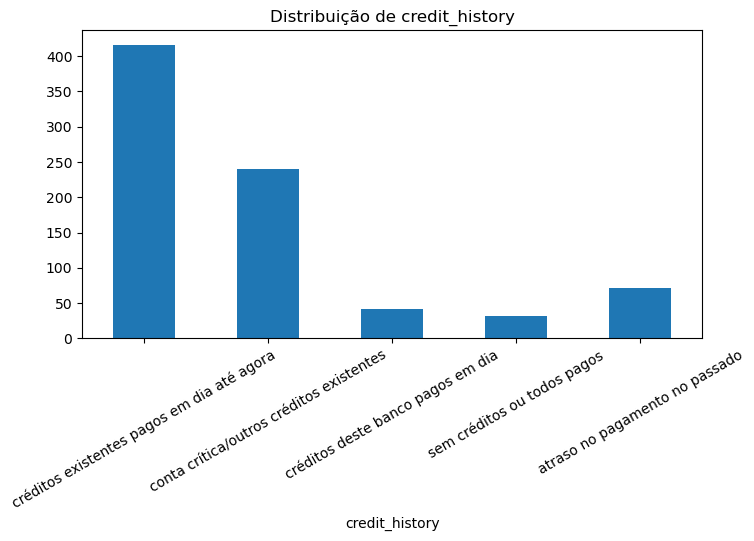

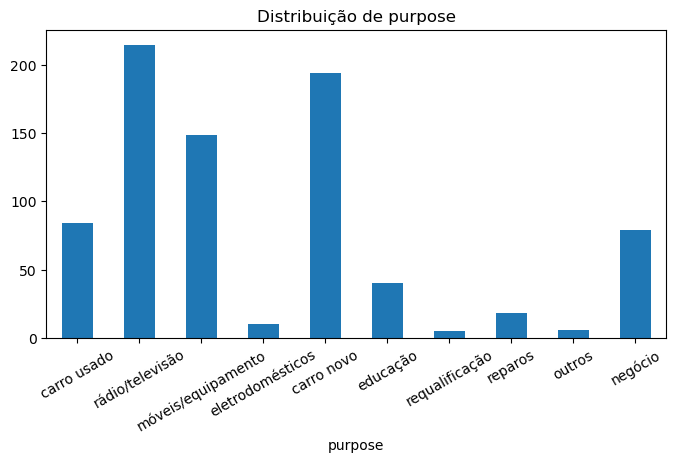

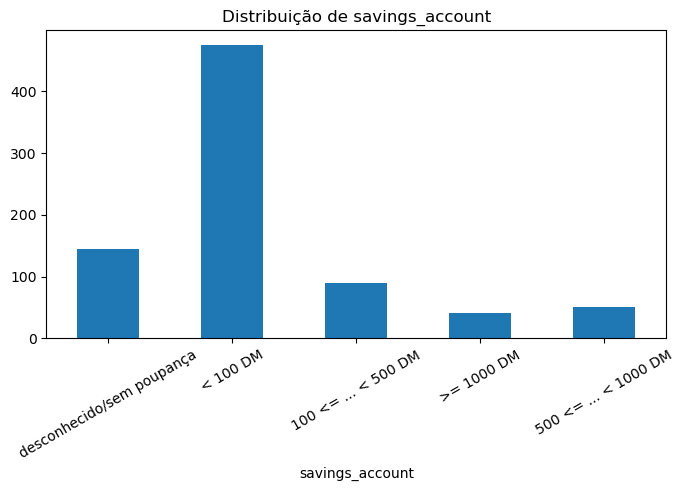

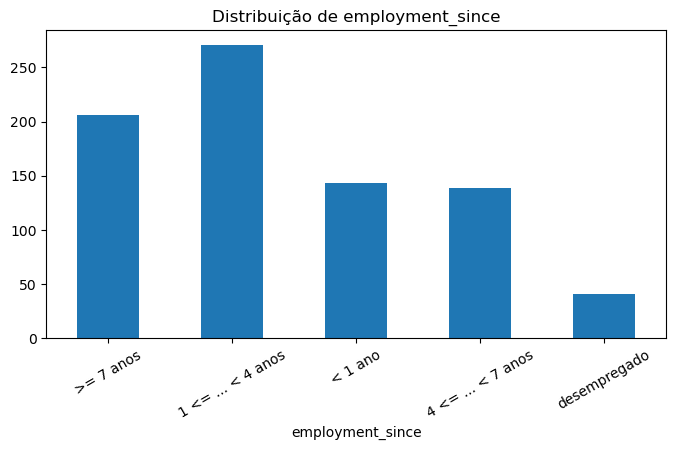

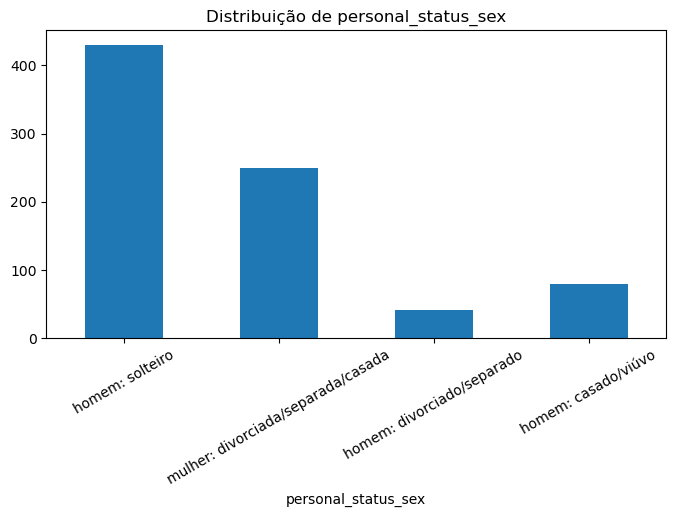

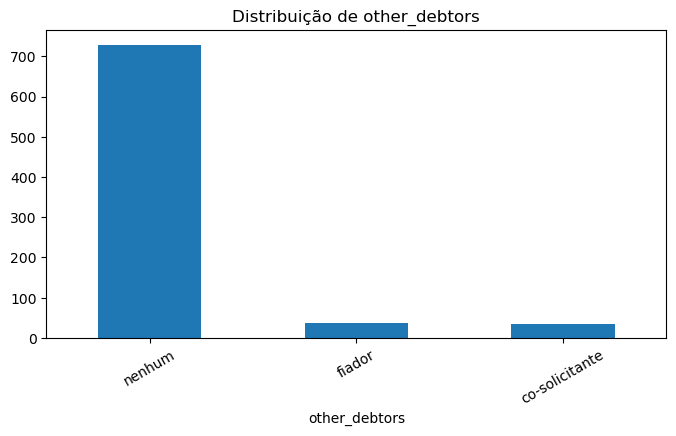

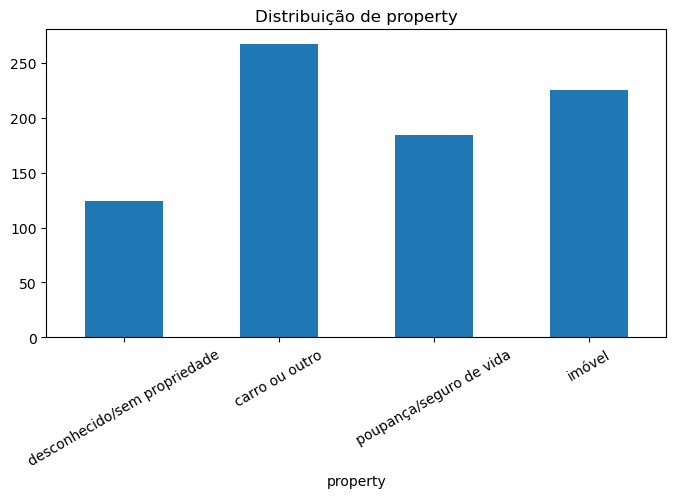

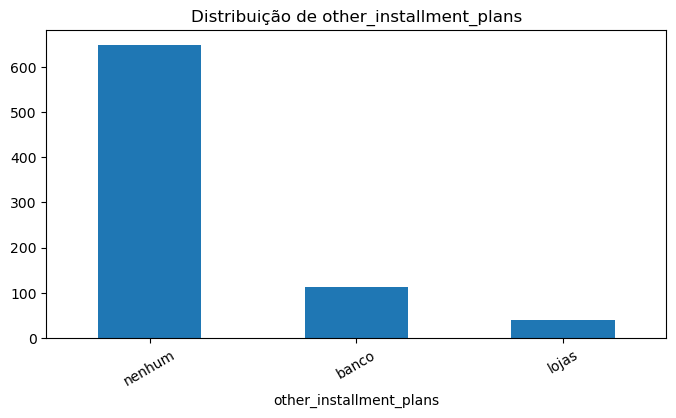

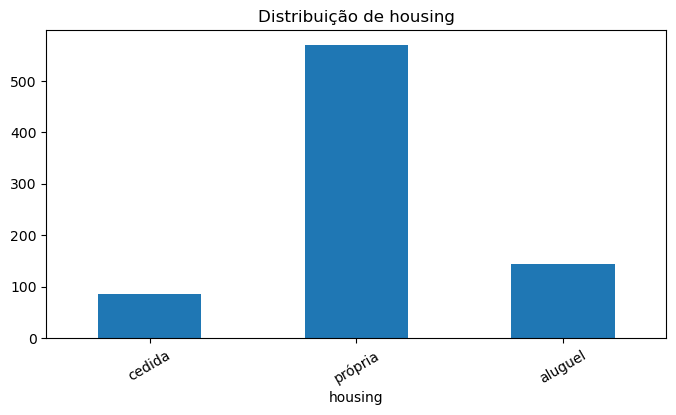

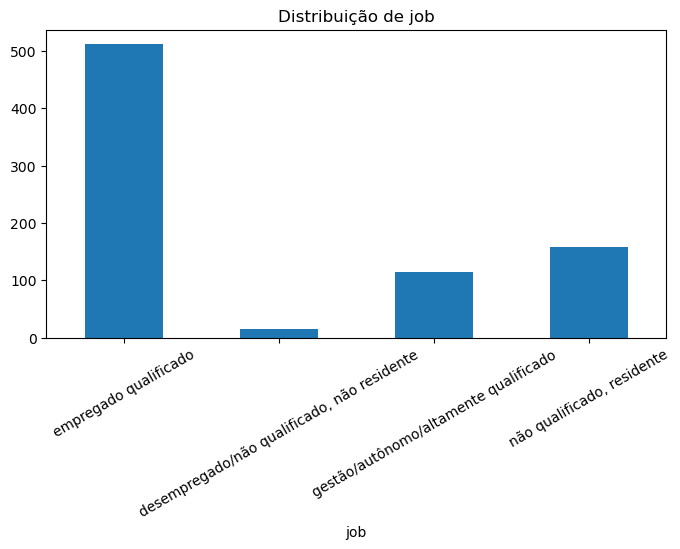

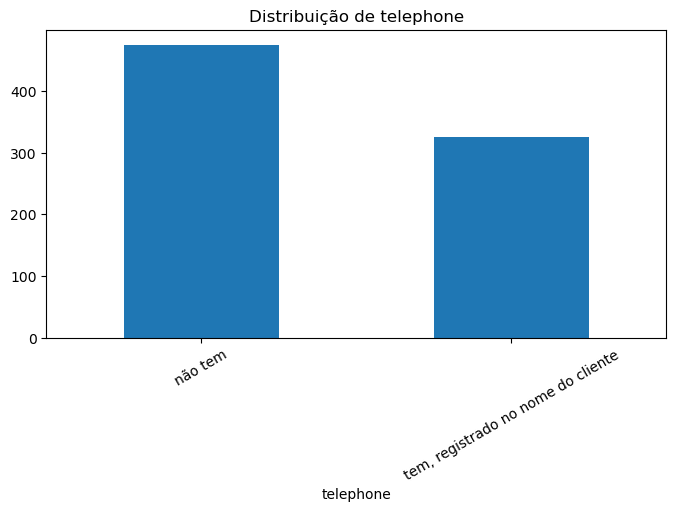

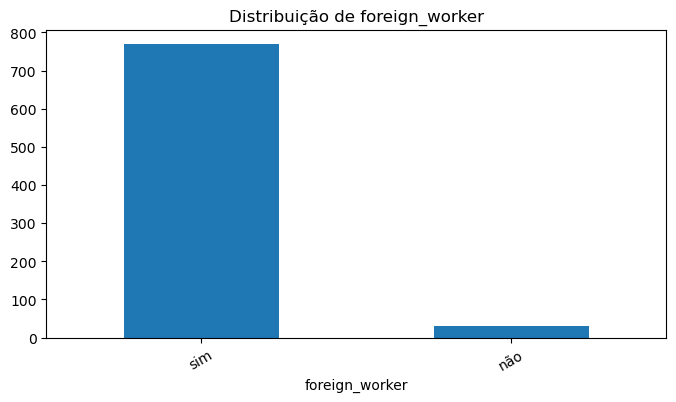

In [16]:
for coluna in features_categoricas:
    treino_decodificado[coluna].value_counts(sort = False).plot(kind='bar', figsize=(8, 4))
    plt.title(f'Distribuição de {coluna}')
    plt.xlabel(coluna)
    plt.xticks(rotation=30)  
    plt.show()

INSIGHT:

    - em credit_history podemos perceber que quase todos os clientes possuem ou ja possui algum outro emprestimo, existem uma boa proporcao de cleinte que ja haviam outros creditos 
    - a quantidade de homen e aproximadamente o dobro das mulheres, dentro os homens grande parte sãio homens solteiros
    - pessoas que fazem emprestimo normalemnte nao tem grandes valores na conta poupança/corrente, fazendo sentido o pedido de emprestimo
    - grande parte possui casa propria
    - grande parte possui um emprego qualificado
    - quase todos os cliente sao estrangeiros

## analise multivariada

CORRELACAO

In [17]:
corr_matrix = treino.corr(numeric_only=True)
corr_matrix['credit_risk'].sort_values(key=abs, ascending= True)

residence_since     0.001965
dependents          0.011905
existing_credits   -0.047149
age                -0.057750
installment_rate    0.080345
credit_amount       0.138776
duration_months     0.206301
credit_risk         1.000000
Name: credit_risk, dtype: float64

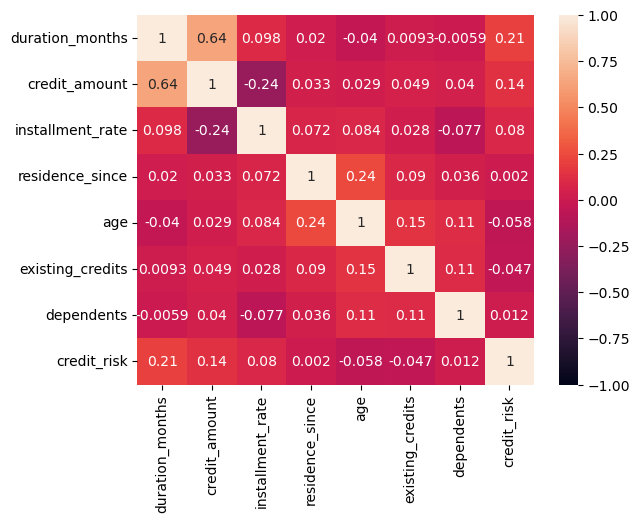

In [18]:
sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True)
plt.show()

INSIGHTS

    - duration_months: 0,21 → correlação positiva fraca, prazos mais longos tendem a estar associados a mau pagador 
    - credit_amount: 0,14 → mesma lógica, positiva fraca: valores de crédito mais altos tendem a puxar pro lado de mau pagador
    - age: -0,058 → negativa (fraca): idade mais alta tende a puxar pro lado de bom pagador, clientes mais velhos parecem levemente menos arriscados
    - installment_rate, residence_since, existing_credits, dependents: todas muito perto de 0 (0,08 a -0,05) → praticamente nenhuma relação linear direta com o risco isoladamente
    - duration_months × credit_amount, credit_amount × installment_rate e age × residence_since: os três pares mais fortes fora do target — confere os valores exatos direto no heatmap da célula abaixo, porque mudaram um pouco com o novo split e eu não tenho os dados brutos aqui pra recalcular

    sera possivel ver essas relacao nos graficos abaixos

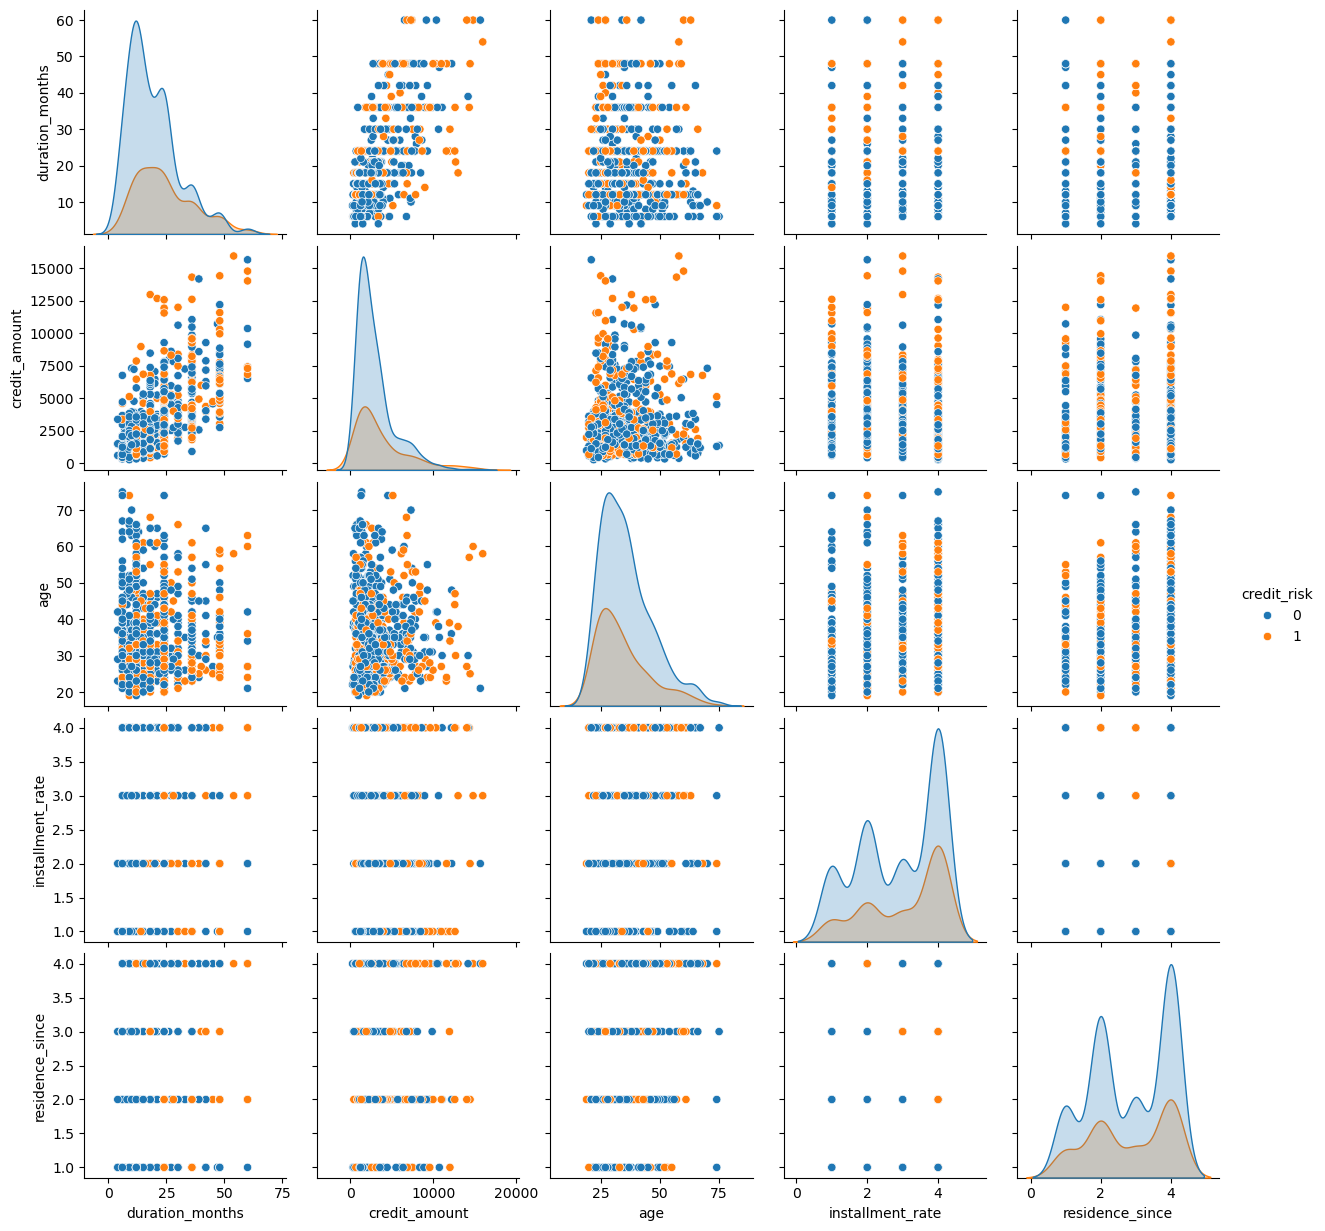

In [19]:
sns.pairplot(data=treino, hue='credit_risk', vars=['duration_months','credit_amount','age','installment_rate','residence_since',])#colocar as colunas que quero ver
plt.show()

### Obs: gráficos normalizados por grupo de credit_risk, para comparação proporcional entre bom e mau pagador.

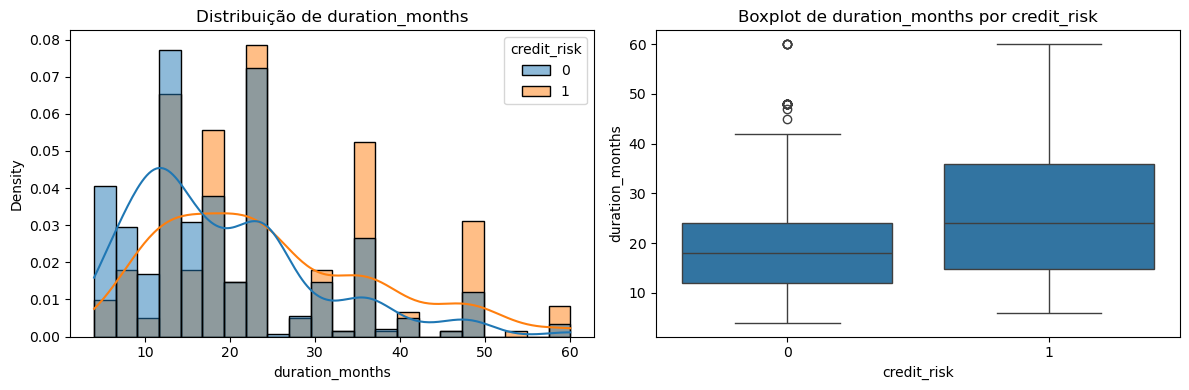

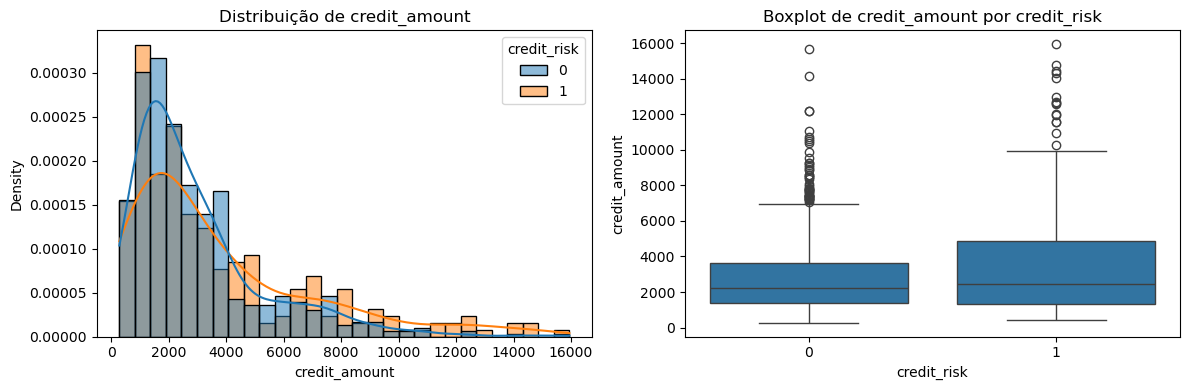

In [20]:
sns_plots(data=treino, features=['duration_months','credit_amount'], histplot=True, kde=True, hue='credit_risk')

INSIGHTS

    
    novamente podemos perceber que quanto maior a duraçao e maior for a quantia, mais chances do risco de crédito, conseguimos ver isso pelo histograma que inicialmente bons pagadores sao a maioria, enquanto o valor do credito e o tempo aumenta, mals pagadores acaba passando os bons pagadores

### Features categoricas vs objetivo


### Obs: gráficos normalizados por grupo de credit_risk, para comparação proporcional entre bom e mau pagador.

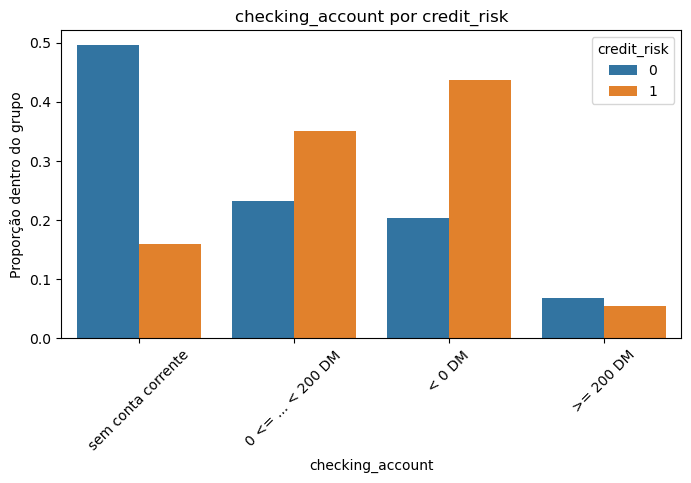

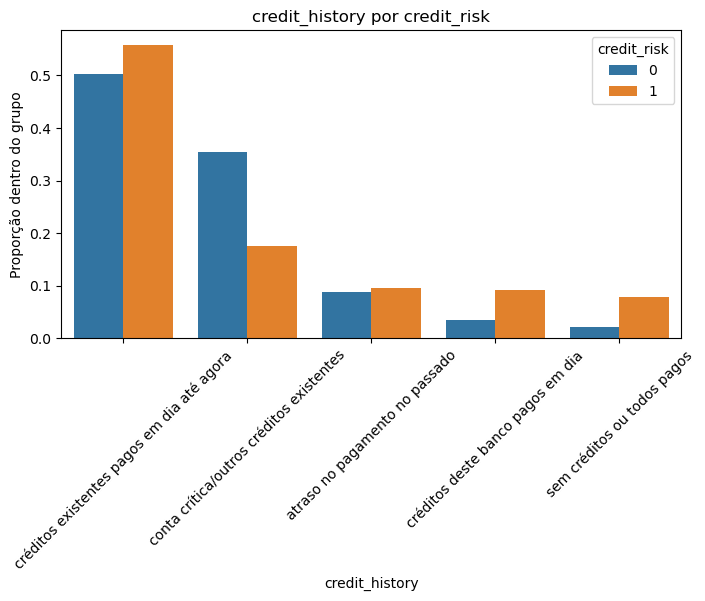

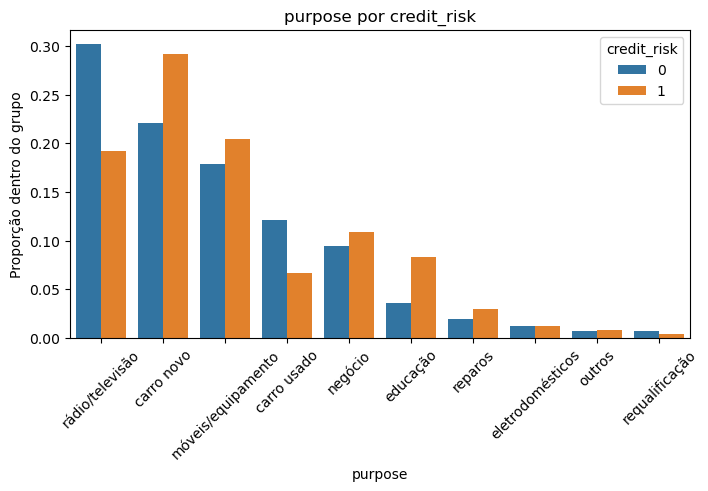

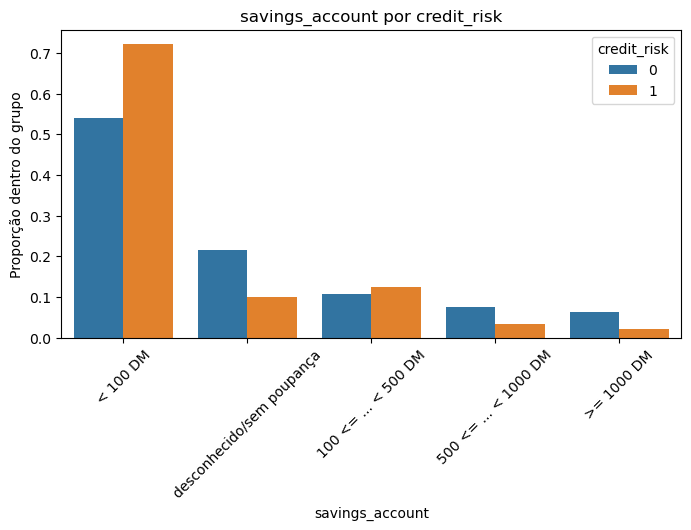

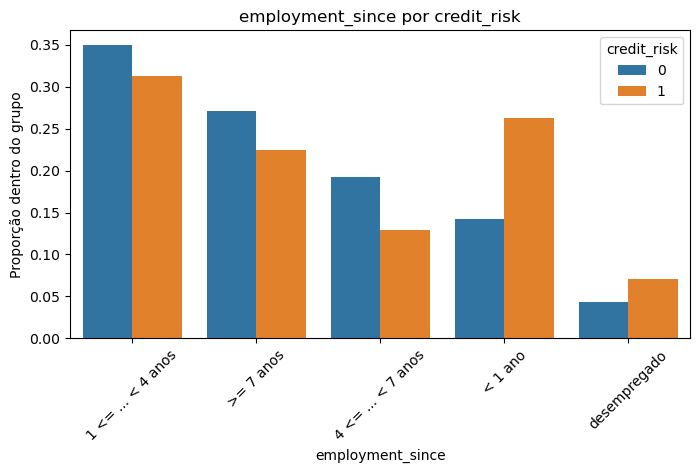

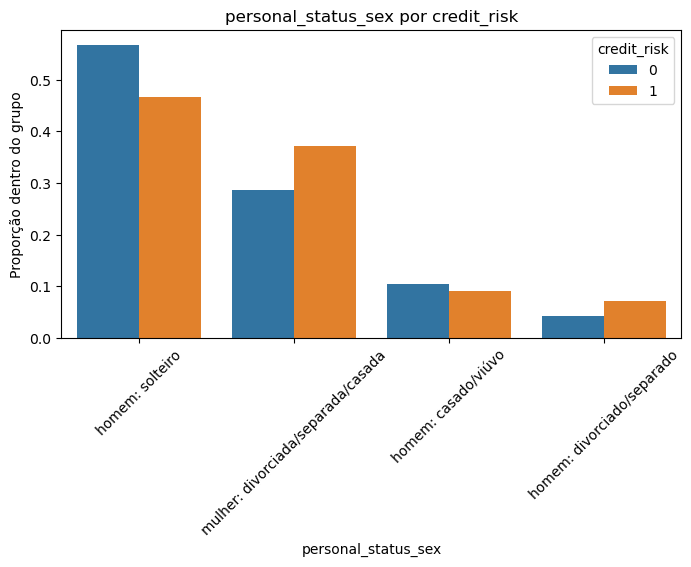

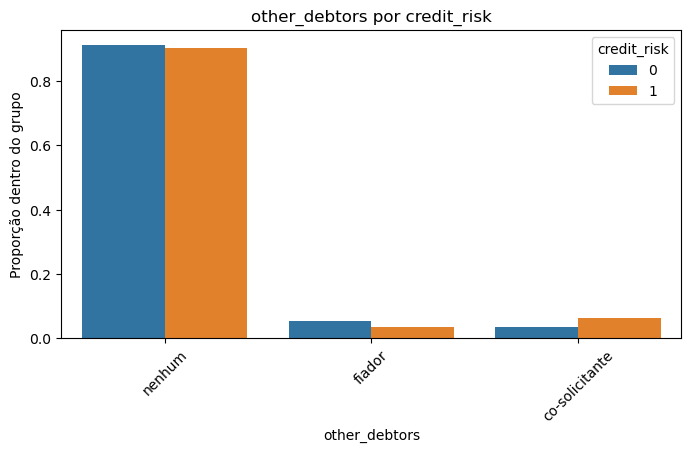

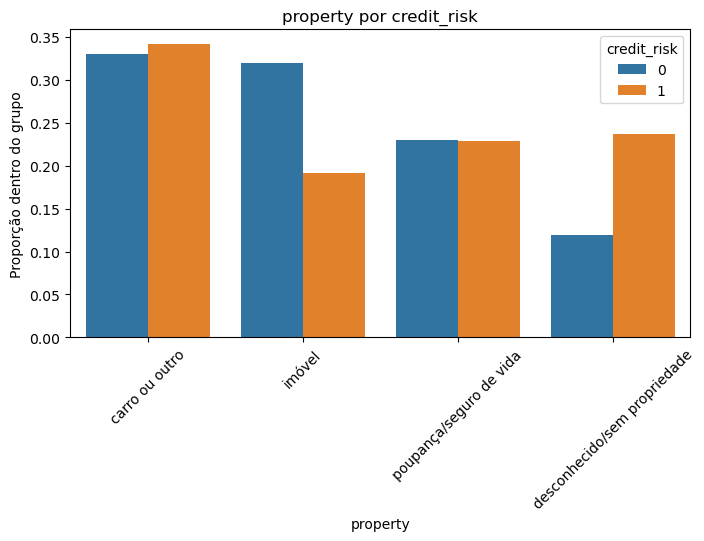

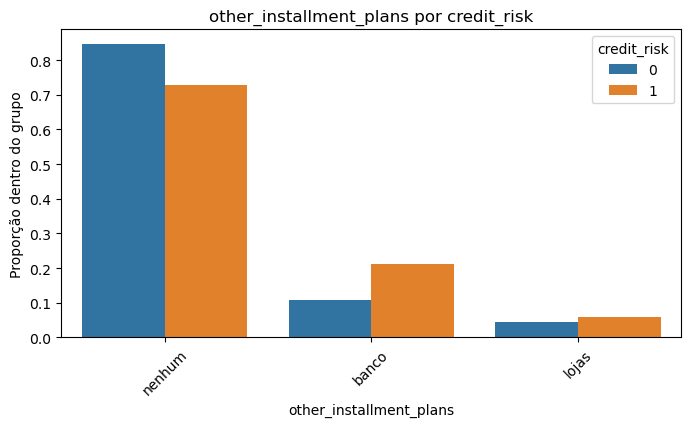

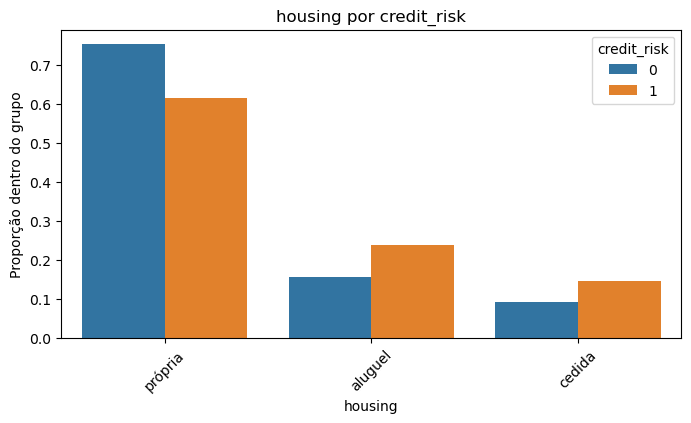

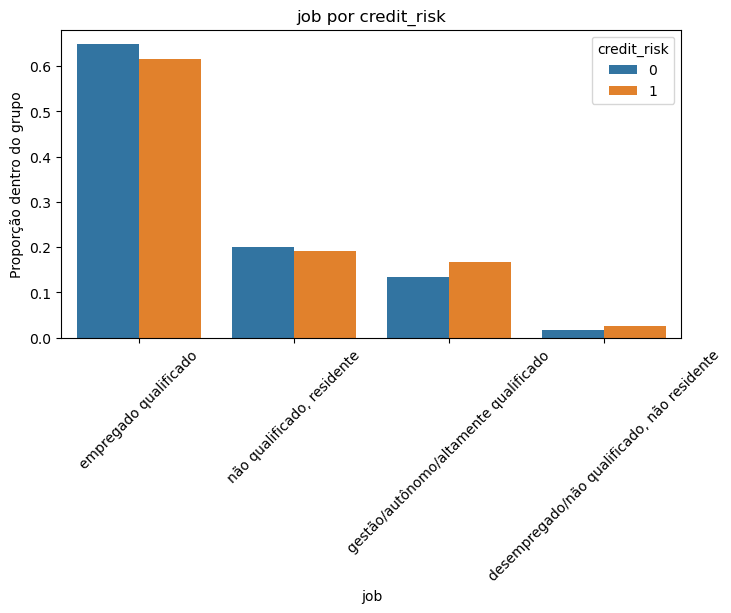

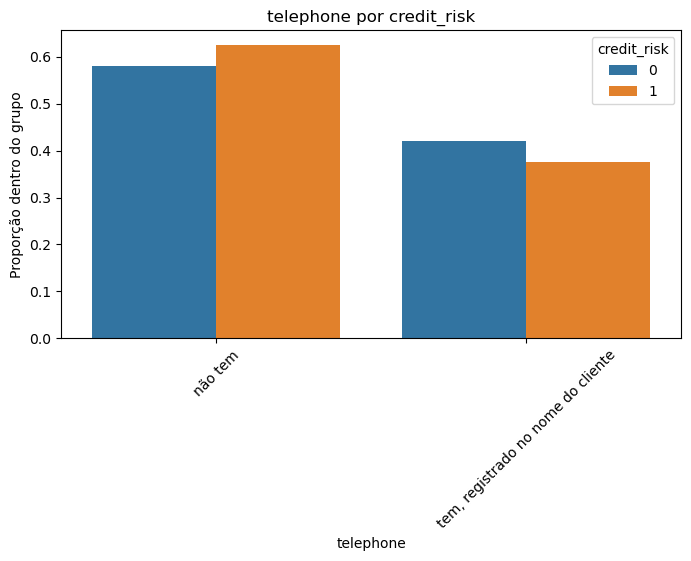

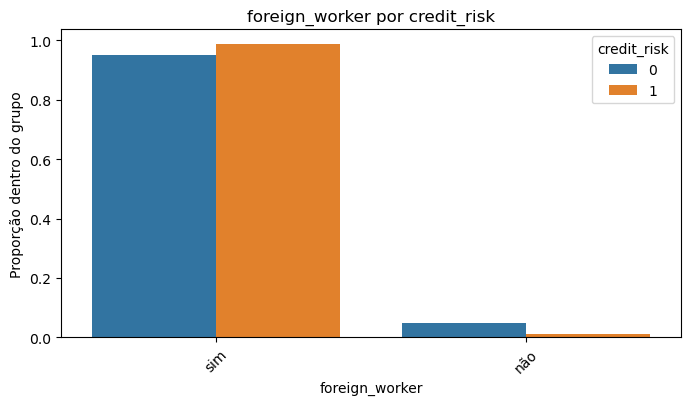

In [21]:
plot_categoricas_bivariada(treino_decodificado, features_categoricas, hue='credit_risk')

INSIGHTS

    - Como esperado pessoas que tem pouco valor monetário na conta corrente/poupança tende a altos riscos de credito, isso tambem reflete no inverso, pessoas que tem grande valor monetario tende a ter riscos baixos
    - pessoas que usaram o dinheiro para educaçaõ tende a ser de alto risco, podemos ver que para prositos de auto valor como carro novo ou negocios tambem tende a ser de alto risco confirmando a nossa hipotese anterior
    - pessoas com menos tempo de serviço tende a maiores riscos, isso vai favor da hipotese dos valor guardados nos bancos, menor tempo de trabalho implica menos poupança
    - homens divorciado tendem a ter maiores riscos, mulheres tambem tendem a riscos porem com menos intensidade a homnen divorciados
    - Pessoas que nao colocam algo como propridade como garantia tendem a ser ter mais riscos
    - Um achado interessante é que clientes com histórico "em dia até agora" tendem a apresentar, proporcionalmente, mais risco de crédito do que clientes classificados como "conta crítica/outros créditos existentes" — categoria que, pelo nome, sugere pior histórico. Uma possível explicação é que o banco já aplique uma filtragem prévia: clientes com esse tipo de histórico só recebem novo crédito quando existe algum indício forte de que vão honrar o pagamento, funcionando como uma espécie de "peneira" adicional. Isso pode compensar (ou até superar) o risco aparente da categoria, explicando por que esses clientes acabam apresentando, na prática, menos inadimplência.

In [22]:
amount_duration_risk = treino.groupby('credit_risk', as_index=False).agg({'credit_amount': 'sum', 'duration_months': 'mean'})
amount_duration_risk['percentual'] = amount_duration_risk['credit_amount'] / amount_duration_risk['credit_amount'].sum()
print(amount_duration_risk)

   credit_risk  credit_amount  duration_months  percentual
0            0        1650236        19.175000    0.646727
1            1         901437        24.491667    0.353273


Maus pagadores (grupo 1) representam 30% dos clientes, mas correspondem a 35,33% do valor total emprestado — ou seja, proporcionalmente mais dinheiro do que sua fatia de clientes sugere
A duração média de crédito dos maus pagadores (24,49 meses) é bem maior que a dos bons pagadores (19,18 meses) — confirma de novo o padrão que já tínhamos visto anteriormente

## Conclusões do EDA


### Perfil Geral do clientes:
    
    - A maioria dos clientes tem entre 20 e 40 anos, é homem (cerca do dobro das mulheres) e solteiro. O perfil típico tem emprego qualificado, casa própria, histórico de crédito em dia  e pouco saldo em conta corrente ou poupança, coerente com o motivo de buscar um empréstimo. Quase todos são trabalhadores estrangeiros.

### O que mais se relaciona com o risco:

    - Tempo e valor do crédito: prazos mais longos e valores mais altos de empréstimo estão associados a mais risco — as duas variáveis com maior correlação com o target (0,21 e 0,14), e também correlacionadas fortemente entre si (0,64), sugerindo que "pedidos maiores e mais longos" formam um perfil de risco combinado, não dois efeitos independentes.
    
    -Estabilidade financeira: clientes com pouco ou nenhum saldo em conta corrente/poupança, e com menos tempo no mercado de trabalho, apresentam mais risco, reforça a hipótese de que reserva financeira e estabilidade profissional protegem contra a inadimplência.
    
    - Finalidade do crédito: pedidos para educação, carro novo e negócios concentram mais risco que outras finalidades (como eletrodomésticos ou reparos)
    
    - Perfil pessoal: homens divorciados apresentaram a maior proporção de risco entre as categorias de estado civil; mulheres também aparecem com risco elevado, mas em menor intensidade.
    
    - Garantias: clientes sem nenhuma propriedade declarada como garantia tendem a apresentar mais risco.

    - Achado contraintuitivo: clientes com histórico "conta crítica/outros créditos existentes" (nome que sugere pior histórico) apresentaram, proporcionalmente, menos risco que clientes "em dia até agora". A hipótese mais provável é que o banco já aplique uma filtragem prévia nesses casos, só aprovando novo crédito quando há forte indício de pagamento.

### Impacto Financeiro:

    - Maus pagadores representam 30% dos clientes, mas 35,33% do valor total emprestado — uma fatia desproporcional ao tamanho do grupo, o que reforça o custo real da inadimplência para o banco.



    
        